# `torch.compile` & CUDA Graphs

At batch size 1, a decode step is hundreds of tiny kernels, each finishing faster
than the CPU can launch the next, so generation speed is set by launch overhead,
not FLOPs or bandwidth. This notebook measures that overhead and removes it two
ways:

1. **Part 1**: measure per-launch overhead and find the tensor size below which
   a kernel is effectively free (launch-bound).
2. **Part 2**: `torch.compile`. What graph breaks are, how to find them with
   `torch._dynamo.explain`, and how to rewrite a decode step to compile as one
   graph (`fullgraph=True`).
3. **Part 3**: capture a decode step into a CUDA graph by hand with
   `torch.cuda.CUDAGraph` (static buffers, side-stream warmup, replay): what
   `torch.compile(mode="reduce-overhead")` automates.

Parts 1-2 run anywhere; Part 3 and the final benchmark need a GPU.

## What's implemented

| Part | Function |
|------|----------|
| 1 | `sweep_elementwise_times` + `estimate_launch_overhead_us` |
| 2 | `fixed_decode_step`: same math as the broken step, zero graph breaks |
| 3 | `make_graphed_callable`: manual CUDA-graph capture + replay |
| 4 | Analysis |

## Cell types

- **HARNESS**: fixed timer, offender, and benchmark cells.
- **IMPLEMENTATION**: the functions built here.
- **SELF-CHECK**: asserts that must pass.
- **ANALYSIS**: findings, argued from the measured numbers.

Run top-to-bottom on a GPU. Artifacts land in `results/03_compile_cuda_graphs/`.


## Setup (fixed harness)


In [1]:
# HARNESS - device + a known-good timer.
import contextlib, io, math, os, time

import torch
from torch import _dynamo as dynamo

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RESULTS_DIR = os.path.join("results", "03_compile_cuda_graphs")
os.makedirs(RESULTS_DIR, exist_ok=True)

torch.set_grad_enabled(False)   # inference-only workload

print(f"torch {torch.__version__}  device={DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))


def bench(fn, n_warmup: int = 10, n_iters: int = 100) -> float:
    """Average seconds per call - CUDA-event timing on GPU, perf_counter on CPU.
    (the same CUDA-event timer built in notebook 01.)"""
    for _ in range(n_warmup):
        fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        for _ in range(n_iters):
            fn()
        end.record()
        torch.cuda.synchronize()
        return start.elapsed_time(end) / 1e3 / n_iters
    t0 = time.perf_counter()
    for _ in range(n_iters):
        fn()
    return (time.perf_counter() - t0) / n_iters

torch 2.11.0+cu128  device=cuda (NVIDIA A100-SXM4-40GB)


## Part 1 - cost of one kernel launch

A CUDA kernel launch costs the CPU a few microseconds (driver call, queueing)
regardless of how much work the kernel does. For a tiny tensor the GPU finishes
almost instantly, so the wall time is nearly pure launch overhead; only past some
size does the actual work dominate. Sweep one elementwise op across sizes and
find that knee.

In [2]:
# IMPLEMENTATION: sweep_elementwise_times
def sweep_elementwise_times(sizes: list) -> list:
    """For each element count n in `sizes`: build a 1-D fp32 tensor of n elements
    on DEVICE and time ONE out-of-place elementwise op over it (e.g. x + 1.0)
    with bench(). Return seconds-per-call for each size, same order.

    Use the SAME op for every size - the point is to see where time STOPS
    depending on n.
    """
    times = []
    for n in sizes:
        x = torch.ones(n, dtype=torch.float32, device=DEVICE)
        # default-arg binding so the lambda captures THIS x, not the loop var;
        # `x + 1.0` is out-of-place (fresh output tensor each call).
        times.append(bench(lambda x=x: x + 1.0))
    return times


def estimate_launch_overhead_us(sizes: list, times: list) -> float:
    """Estimate the per-launch overhead in MICROseconds from your sweep:
    average the seconds-per-call over the clearly launch-bound sizes
    (say n <= 2**12) and convert to µs."""
    launch_bound = [t for n, t in zip(sizes, times) if n <= 2 ** 12]
    return (sum(launch_bound) / len(launch_bound)) * 1e6

n =          1      11.60 us/call
n =          4      11.40 us/call
n =         16      11.11 us/call
n =         64      10.79 us/call
n =        256      10.97 us/call
n =      1,024      11.07 us/call
n =      4,096      10.93 us/call
n =     16,384      10.86 us/call
n =     65,536      10.80 us/call
n =    262,144      11.16 us/call
n =  1,048,576      10.92 us/call
n =  4,194,304      22.26 us/call
n = 16,777,216     101.40 us/call

estimated per-launch overhead = 11.12 us


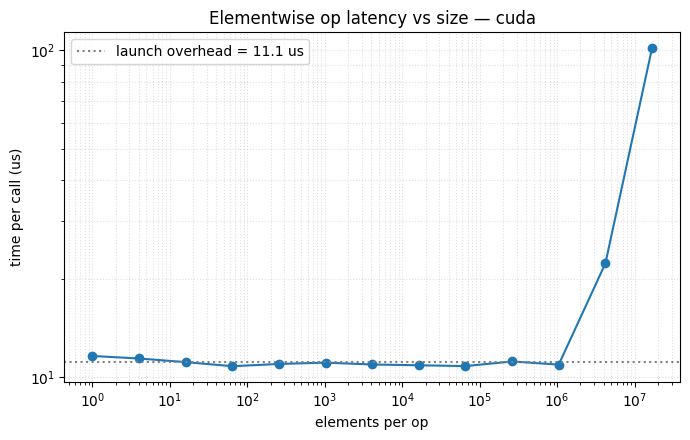

In [3]:
# HARNESS - run the sweep + plot.
SIZES = [2 ** k for k in range(0, 25, 2)]
times = sweep_elementwise_times(SIZES)
assert len(times) == len(SIZES), "one measurement per size"
overhead_us = estimate_launch_overhead_us(SIZES, times)

for n, t in zip(SIZES, times):
    print(f"n = {n:>10,}   {t * 1e6:8.2f} us/call")
print(f"\nestimated per-launch overhead = {overhead_us:.2f} us")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(SIZES, [t * 1e6 for t in times], "o-")
ax.axhline(overhead_us, ls=":", c="gray",
           label=f"launch overhead = {overhead_us:.1f} us")
ax.set_xlabel("elements per op")
ax.set_ylabel("time per call (us)")
ax.set_title(f"Elementwise op latency vs size - {DEVICE}")
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "launch_overhead.png"), dpi=130)
plt.show()

## Part 2 - `torch.compile` and graph breaks

`torch.compile` traces Python into a graph (TorchDynamo) and compiles it into
fused kernels (TorchInductor). The trace breaks whenever the code needs a real
Python value from tensor data: `.item()`, `print(tensor)`, an `if` on a tensor.
Each break splits the function into separate compiled chunks with eager glue
between them (no fusion across the break), and `.item()` also forces the CPU to
wait for the GPU.

`broken_decode_step` below uses three such constructs. Run the `explain` cell to
see the breaks (it may report fewer than three - once dynamo falls back to Python
it can swallow several in one gap). Then write `fixed_decode_step`: the same math
(minus the print), compilable as one graph.

In [4]:
# HARNESS - the offender.
def broken_decode_step(h: torch.Tensor, state: torch.Tensor):
    """One step of a toy recurrent decode update. Correct, but hard to compile."""
    # 1) rms-normalize
    h = h * torch.rsqrt(h.pow(2).mean(dim=-1, keepdim=True) + 1e-6)
    # 2) rescale if the max |value| is large - via a host round-trip
    scale = h.abs().max().item()          # GPU -> CPU sync + graph break
    if scale > 3.0:                       # Python branch on tensor data
        h = h / scale
    # 3) progress logging on the hot path
    print(f"max|h| = {scale:.3f}")        # graph break
    # 4) EMA state update
    state = 0.9 * state + 0.1 * h
    return h, state

In [5]:
# HARNESS - dynamo's diagnosis of the offender.
dynamo.reset()
_h = torch.randn(2, 64, device=DEVICE)
_s = torch.zeros(2, 64, device=DEVICE)
with contextlib.redirect_stdout(io.StringIO()):  # mute the print inside
    explanation = dynamo.explain(broken_decode_step)(_h, _s)
print(f"graphs produced : {explanation.graph_count}")
print(f"graph breaks    : {explanation.graph_break_count}")
for i, reason in enumerate(explanation.break_reasons):
    print(f"  break {i}: {str(reason.reason).splitlines()[0]}")

W0630 01:52:02.262000 2875 torch/_dynamo/variables/tensor.py:1379] [0/0] Graph break from `Tensor.item()`, consider setting:
W0630 01:52:02.262000 2875 torch/_dynamo/variables/tensor.py:1379] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0630 01:52:02.262000 2875 torch/_dynamo/variables/tensor.py:1379] [0/0] or:
W0630 01:52:02.262000 2875 torch/_dynamo/variables/tensor.py:1379] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0630 01:52:02.262000 2875 torch/_dynamo/variables/tensor.py:1379] [0/0] to include these operations in the captured graph.
W0630 01:52:02.262000 2875 torch/_dynamo/variables/tensor.py:1379] [0/0] 
W0630 01:52:02.262000 2875 torch/_dynamo/variables/tensor.py:1379] [0/0] Graph break: from user code at:
W0630 01:52:02.262000 2875 torch/_dynamo/variables/tensor.py:1379] [0/0]   File "/tmp/ipykernel_2875/926770593.py", line 7, in broken_decode_step
W0630 01:52:02.262000 2875 torch/_dynamo/variables/tensor.py:1379] [0/0]     scale = h.abs().max().item

graphs produced : 2
graph breaks    : 1
  break 0: Unsupported Tensor.item() call with capture_scalar_outputs=False


In [6]:
# IMPLEMENTATION: fixed_decode_step
def fixed_decode_step(h: torch.Tensor, state: torch.Tensor):
    """Same math as broken_decode_step (minus the print), with ZERO graph
    breaks - it must run under torch.compile(..., fullgraph=True).

    Hints:
      * Keep `scale` as a 0-dim TENSOR - never call .item() on the hot path.
      * torch.where can replace the Python `if` (both sides get computed;
        that's fine - it keeps everything on the GPU).
      * Logging has no place in a hot loop - drop the print.
    """
    # 1) rms-normalize (unchanged)
    h = h * torch.rsqrt(h.pow(2).mean(dim=-1, keepdim=True) + 1e-6)
    # 2) rescale if the max |value| is large - stay on-device:
    #    scale is a 0-dim tensor (no .item()); torch.where replaces the branch.
    scale = h.abs().max()                       # 0-dim tensor, no host sync
    h = torch.where(scale > 3.0, h / scale, h)  # same result as `if scale > 3.0`
    # 3) print dropped - no logging on the hot path
    # 4) EMA state update (unchanged)
    state = 0.9 * state + 0.1 * h
    return h, state

In [7]:
# SELF-CHECK - fixed asserts.
torch.manual_seed(0)

_big = torch.zeros(2, 64, device=DEVICE); _big[0, 0] = 100.0  # forces the rescale branch
_flat = torch.ones(2, 64, device=DEVICE)                      # avoids it
_cases = [_big, _flat] + [torch.randn(2, 64, device=DEVICE) * 3 for _ in range(4)]

for _i, _hc in enumerate(_cases):
    _sc = torch.randn(2, 64, device=DEVICE)
    with contextlib.redirect_stdout(io.StringIO()):  # mute broken's print
        _h_ref, _s_ref = broken_decode_step(_hc.clone(), _sc.clone())
    _h_new, _s_new = fixed_decode_step(_hc.clone(), _sc.clone())
    assert torch.allclose(_h_ref, _h_new, atol=1e-6), f"h mismatch on case {_i}"
    assert torch.allclose(_s_ref, _s_new, atol=1e-6), f"state mismatch on case {_i}"
print("same math as the broken step       PASS")

# backend="eager" skips kernel codegen - this tests ONLY the dynamo trace,
# so it passes/fails identically on CPU and GPU.
dynamo.reset()
_compiled = torch.compile(fixed_decode_step, fullgraph=True, backend="eager")
_compiled(torch.randn(2, 64, device=DEVICE), torch.zeros(2, 64, device=DEVICE))
print("compiles with fullgraph=True       PASS")

dynamo.reset()
_ex = dynamo.explain(fixed_decode_step)(torch.randn(2, 64, device=DEVICE),
                                        torch.zeros(2, 64, device=DEVICE))
assert _ex.graph_break_count == 0, f"{_ex.graph_break_count} graph break(s) remain"
print("0 graph breaks                     PASS")
print()
print("All checks passed")

same math as the broken step       PASS
compiles with fullgraph=True       PASS
0 graph breaks                     PASS

All checks passed


In [8]:
# HARNESS - what the fix buys: broken-eager vs fixed-compiled.
_h = torch.randn(2, 64, device=DEVICE)
_s = torch.zeros(2, 64, device=DEVICE)

with contextlib.redirect_stdout(io.StringIO()):   # mute 100+ prints
    t_broken = bench(lambda: broken_decode_step(_h, _s), n_warmup=3, n_iters=50)

dynamo.reset()
_compiled_fixed = torch.compile(fixed_decode_step)
try:
    t_fixed = bench(lambda: _compiled_fixed(_h, _s), n_warmup=10, n_iters=50)
    tag = "compiled, one graph"
except Exception as e:
    print(f"inductor backend unavailable here ({type(e).__name__}) - timing eager fixed instead.")
    t_fixed = bench(lambda: fixed_decode_step(_h, _s), n_warmup=3, n_iters=50)
    tag = "eager (compile unavailable)"

print(f"broken (eager, sync + print): {t_broken*1e6:8.1f} us/step")
print(f"fixed  ({tag}): {t_fixed*1e6:8.1f} us/step   ({t_broken/t_fixed:.1f}x)")
if DEVICE == "cpu":
    print()
    print("Note: on CPU a 'sync' costs nothing (CPU execution is synchronous"
          " already), so the gap here is small or even negative. The GPU run"
          " is the one that counts.")

broken (eager, sync + print):    150.6 us/step
fixed  (compiled, one graph):     77.1 us/step   (2.0x)


## Part 3 - CUDA graphs by hand

A CUDA graph records the exact sequence of kernels (and their memory addresses)
once, then replays the whole sequence with a single launch - turning N launches
into 1, which is what a launch-bound decode loop needs.

The cost is rigidity: replay uses the same memory and same shapes every time. So:
- inputs must live in a static buffer you `copy_` new data into;
- outputs come back in a static buffer that the next replay overwrites;
- nothing inside may sync with the host, allocate new memory, or change shape.

`torch.compile(mode="reduce-overhead")` does this for you; here you do it by hand.
The step below is a 4-block MLP at batch 1 - dozens of small kernels.

In [9]:
# HARNESS - the toy decode step.
class TinyDecoder(torch.nn.Module):
    def __init__(self, d: int = 256, hidden: int = 1024, blocks: int = 4):
        super().__init__()
        self.blocks = torch.nn.ModuleList(
            torch.nn.Sequential(
                torch.nn.LayerNorm(d),
                torch.nn.Linear(d, hidden),
                torch.nn.GELU(),
                torch.nn.Linear(hidden, d),
            ) for _ in range(blocks))

    def forward(self, x):
        for blk in self.blocks:
            x = x + blk(x)
        return x


torch.manual_seed(0)
decoder = TinyDecoder().to(DEVICE).eval()
for p in decoder.parameters():
    p.requires_grad_(False)
example = torch.randn(1, 256, device=DEVICE)
print(decoder(example).shape)

torch.Size([1, 256])


In [10]:
# IMPLEMENTATION: make_graphed_callable
def make_graphed_callable(fn, example_input: torch.Tensor):
    """Capture `fn(example_input)` into a CUDA graph; return `graphed(x)` that
    replays it for new inputs of the same shape/dtype.

    Recipe (see torch.cuda.CUDAGraph docs):
      1. static_in = example_input.clone()
      2. Warm up on a SIDE STREAM (capture fails on a stream with pending work):
             s = torch.cuda.Stream()
             s.wait_stream(torch.cuda.current_stream())
             with torch.cuda.stream(s): ...warmup...
             torch.cuda.current_stream().wait_stream(s)
      3. Capture once:
             g = torch.cuda.CUDAGraph()
             with torch.cuda.graph(g):
                 static_out = fn(static_in)
      4. graphed(x): copy_ x into static_in, g.replay(), return static_out.clone()
         (the next replay overwrites static_out).

    Skipping the copy_ in step 4 makes the graph keep recomputing on stale input;
    the self-check below catches it.
    """
    # 1) static input buffer the graph will always read from
    static_in = example_input.clone()

    # 2) warm up on a side stream (cuBLAS/codegen init must NOT happen mid-capture)
    s = torch.cuda.Stream()
    s.wait_stream(torch.cuda.current_stream())
    with torch.cuda.stream(s):
        for _ in range(3):
            fn(static_in)
    torch.cuda.current_stream().wait_stream(s)

    # 3) capture the kernel sequence once; static_out is the graph's output buffer
    g = torch.cuda.CUDAGraph()
    with torch.cuda.graph(g):
        static_out = fn(static_in)

    # 4) replay: feed new data through the static buffers, clone the result out
    def graphed(x: torch.Tensor) -> torch.Tensor:
        static_in.copy_(x)            # new input into the buffer the graph reads
        g.replay()                    # N launches -> 1
        return static_out.clone()     # copy out before the next replay overwrites it

    return graphed

In [11]:
# SELF-CHECK - fixed asserts. (GPU only - SKIPs on CPU.)
if DEVICE == "cuda":
    graphed = make_graphed_callable(decoder, example)
    for _i in range(3):
        _xin = torch.randn(1, 256, device=DEVICE)
        _ref = decoder(_xin)
        _out = graphed(_xin)
        assert torch.allclose(_ref, _out, atol=1e-5), f"mismatch vs eager on input {_i}"
    print("matches eager on fresh inputs      PASS")

    _a = graphed(torch.randn(1, 256, device=DEVICE))
    _b = graphed(torch.randn(1, 256, device=DEVICE))
    assert not torch.allclose(_a, _b), \
        "two different inputs gave the same output - did you copy_ into the static buffer and clone the output?"
    print("static buffers handled correctly   PASS")
    print()
    print("All checks passed")
else:
    print("SKIP - CUDA graphs need a GPU.")

matches eager on fresh inputs      PASS
static buffers handled correctly   PASS

All checks passed


### Final benchmark: 256-step decode, four ways

Each variant generates tokens sequentially (the output of step *t* is the input
of *t+1*). If `reduce-overhead` errors here about overwritten outputs, that's
the static-buffer constraint: explained in analysis §3 rather than worked
around.


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:322: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


torch.compile (reduce-overhead): FAILED (RuntimeError: Error: accessing tensor output of CUDAGraphs that has been overwritten by a subsequent run. Stack trace: File "/tmp/ipykernel_2875/3591268298.py", line 15, in forward
    x = x + blk(x). To prevent overwriting, clone the tensor outside of torch.compile() or call torch.compiler.cudagraph_mark_step_begin() before each model invocation.) - see analysis §3 on CUDA-graph constraints

eager                                 435.6 us/step    1.00x vs eager
manual CUDA graph                      80.9 us/step    5.38x vs eager
torch.compile (default)               446.1 us/step    0.98x vs eager


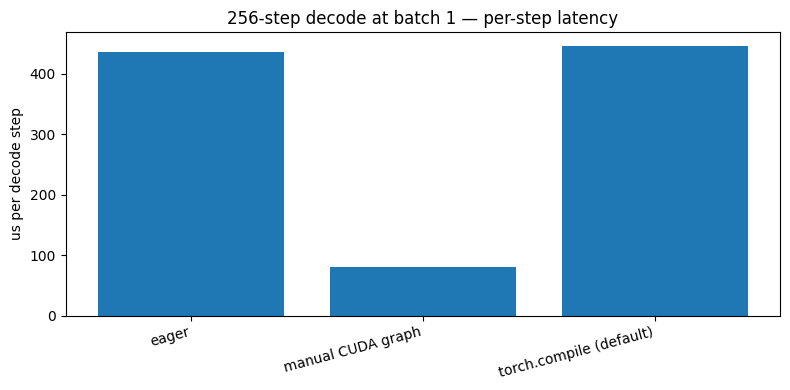

In [12]:
# HARNESS - the final benchmark. (GPU only.)
if DEVICE == "cuda":
    N_STEPS = 256

    def run_decode(step_fn, x0, n_steps=N_STEPS):
        x = x0
        for _ in range(n_steps):
            x = step_fn(x)
        return x

    variants = {"eager": decoder,
                "manual CUDA graph": make_graphed_callable(decoder, example)}
    try:
        dynamo.reset()
        variants["torch.compile (default)"] = torch.compile(decoder)
        variants["torch.compile (reduce-overhead)"] = torch.compile(
            decoder, mode="reduce-overhead")
    except Exception as e:
        print(f"torch.compile unavailable: {type(e).__name__}: {e}")

    times_step = {}
    for name, fn in variants.items():
        try:
            t = bench(lambda: run_decode(fn, example), n_warmup=3, n_iters=10)
            times_step[name] = t / N_STEPS
        except Exception as e:
            print(f"{name}: FAILED ({type(e).__name__}: {e}) "
                  f"- see analysis §3 on CUDA-graph constraints")

    base = times_step["eager"]
    print()
    for name, t in times_step.items():
        print(f"{name:34s} {t*1e6:8.1f} us/step   {base/t:5.2f}x vs eager")

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 4))
    names = list(times_step)
    ax.bar(names, [times_step[n] * 1e6 for n in names], color="tab:blue")
    ax.set_ylabel("us per decode step")
    ax.set_title(f"{N_STEPS}-step decode at batch 1 - per-step latency")
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
    fig.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, "decode_step_latency.png"), dpi=130)
    plt.show()
else:
    print("SKIP - the benchmark needs a GPU.")

---
## Analysis

### 1. Why each construct breaks the graph, and why `.item()` is doubly bad

Dynamo traces tensor *operations* into a graph; it cannot trace any step that
needs a concrete Python value pulled out of tensor *data* at trace time, so
each of these forces a graph break (the trace stops, runs that bit in eager
Python, then starts a new graph after it - no fusion across the gap).

- **`scale = h.abs().max().item()`** - `.item()` asks for a Python `float`, a
  value that only exists once the GPU has actually computed it. Dynamo can't
  put a real number in the graph, so it breaks. **Replaced with** keeping
  `scale` as a 0-dim tensor (`h.abs().max()`), which stays in the graph.
- **`if scale > 3.0:`** - branching on tensor data means the control flow
  depends on a runtime value dynamo doesn't know while tracing; it can't pick a
  branch to bake in, so it breaks. **Replaced with** `torch.where(scale > 3.0,
  h / scale, h)`: both sides are computed on the GPU and the mask selects,
  so there is no data-dependent Python branch.
- **`print(f"max|h| = {scale:.3f}")`** - formatting needs the actual value
  (another read of tensor data) and is a Python side effect dynamo won't trace,
  so it breaks. **Replaced with** removing it - logging has no place in a hot
  loop.

**Why `.item()` is doubly bad:** the other two only cost a graph break (lost
fusion). `.item()` *also* forces a **host sync** - the CPU must stop and wait
for the GPU to finish and copy that one scalar back before it can continue. In
a launch-bound decode loop that serializes CPU and GPU every single step, which
is exactly the overlap we are trying to keep. So `.item()` breaks the graph
**and** stalls the pipeline; the other two only break the graph.


### 2. Why graph replay wins small-batch decode, and the capture constraints

Part 1 showed each kernel launch costs a fixed `~11 us` of CPU time, and that
the per-call time stays flat at ~11 us all the way out to ~10^6 elements (the
knee is near 2^22) - below that, wall time is *all* launch overhead and the GPU
finishes the actual work almost instantly. A batch-1 decode step sits deep in
that regime: dozens of tiny kernels (4 blocks x layernorm/matmul/GELU/matmul),
each so small that the CPU spends more time launching it than the GPU spends
running it. The chain is **launch-bound**, so the CPU launch queue, not the
math, sets the pace.

A CUDA graph records that whole kernel sequence once and replays it with a
**single** launch (N launches -> 1), so the per-step CPU cost collapses to one
replay call. That is why replay wins biggest here: the manual CUDA graph ran at
**80.9 us/step vs eager's 435.6 us, a 5.38x speedup**. It would matter far less
for large-batch / long-sequence work where each kernel is already big enough to
hide its own launch cost. (For contrast, `torch.compile` *default* gave 0.98x -
fusion alone does not cut launch overhead - and `reduce-overhead` errored here;
see the last constraint and §3.)

Constraints I had to respect for capture/replay:
- **Fixed shapes/dtype:** the graph is recorded for one input shape; replay
  only works for the same shape and dtype.
- **Static memory addresses:** replay reuses the exact buffers from capture, so
  inputs must be `copy_`'d into a persistent `static_in`, and the result read
  from a persistent `static_out` (I `clone()` it out before the next replay
  overwrites it).
- **No host sync / no new allocations inside:** nothing in the captured region
  may sync with the CPU or allocate fresh memory; and warmup has to run on a
  **side stream** first, because capture fails on a stream with pending work.
- **This is exactly why `reduce-overhead` FAILED in the chained benchmark:** it
  handed back a tensor living in its static buffer and the next decode step
  overwrote it ("accessing tensor output of CUDAGraphs that has been overwritten
  by a subsequent run"). My manual version dodges this by `clone()`-ing
  `static_out` before returning, so the value survives into the next step - the
  same constraint, handled.


### 3. When `torch.compile` is slower or useless, and how to detect it

**1) Short job / changing shapes - compile latency and recompiles dominate.**
The first call pays a one-time trace+codegen cost (often hundreds of ms to
seconds). If the job is short, or if shapes keep changing so dynamo recompiles
a new graph each time (the classic prefill seq=64 vs decode seq=1, or a growing
KV cache), you pay that cost repeatedly and never amortize it - net slower than
eager. This is exactly why I left `torch.compile` out of notebook 02's
`generate_optimized`.
*Detect:* time with notebook 01's warmup-aware timer - a huge first-call time that does
NOT shrink on later calls means re-compilation; the profiler trace shows the
dynamo/inductor compile frames (or repeated `recompile`/guard-fail events)
reappearing instead of just at startup.

**2) Already hardware-limited kernels - nothing left to fuse away.**
`torch.compile`'s main win is fusing elementwise ops to cut launches and HBM
round-trips. If the hot kernel is one big op already pinned to a hardware
ceiling, there is nothing for fusion to remove and the speedup is ~1x. Two
distinct cases, opposite ends of the roofline:
- a large N x N x N matmul / attention is **compute-bound** - its arithmetic
  intensity grows ~proportional to N (notebook 01, analysis §2), so it sits near the *compute*
  ceiling and cuBLAS already runs it near peak FLOP/s;
- a single big elementwise pass is **bandwidth-bound** - low AI, near the
  *bandwidth* ceiling.

Either way the kernel is hardware-limited, not launch/fusion-limited, so
compile can't help.
*Detect:* put the kernel on the notebook 01 roofline - if it already sits on the
compute ceiling (high AI, near peak TFLOP/s) or the bandwidth ceiling (low AI,
near peak GB/s), it is hardware-limited; the profiler trace (notebook 02's tool) confirms it
(the time is one fat kernel, not many tiny ones with launch gaps between them).

**3) Launch-bound work where only graph *capture* helps, not fusion (measured
this run).** On the batch-1 decode, `torch.compile` *default* came in at
**0.98x** - no help at all. The step is launch-bound, and default mode only
*fuses* kernels; it does not cut the per-launch overhead that dominates, and
there is little elementwise work to fuse in this MLP anyway. The mode that
*would* help, `reduce-overhead` (it wraps the graph in CUDA-graph replay),
errored on the static-buffer constraint (§2). So here the only win came from a
hand-rolled CUDA graph (5.38x), never from `compile`'s fusion.
*Detect:* the profiler trace of this step (notebook 02's tool) is many tiny kernels with launch
gaps between them (not a few fat kernels) -> launch-bound -> only graph
capture/replay cuts the cost, so reach for CUDA graphs, not plain `compile`.
